N (Prosesor)    | Speedup Teoritis
-----------------------------------
2               | 1.7391x
4               | 2.7586x
8               | 3.9024x
16              | 4.9231x
32              | 5.6637x
64              | 6.1244x


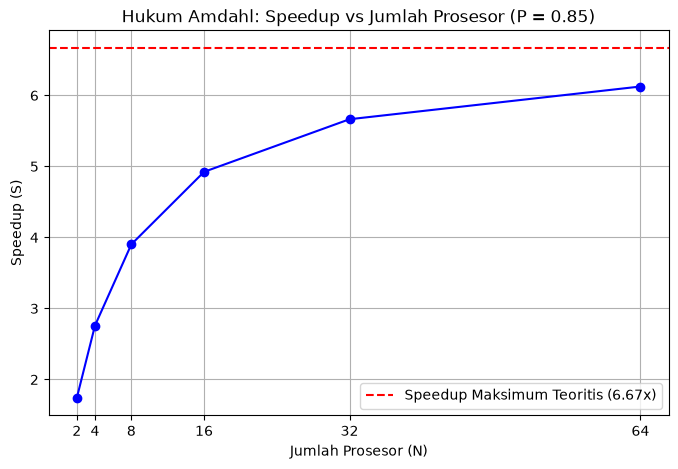

In [ ]:
#Nama: Muhammad Farid Al Hafizh
#Nim: 2411513031
#Kelas A

 
#SOAL 1
#Kategori Flynn untuk operasi ini adalah SIMD (Single Instruction, Multiple Data). 
#Namun, aliran datanya bersifat banyak (Multiple Data), karena prosesor mengeksekusi operasi penjumlahan
#secara serentak terhadap seluruh elemen array NumPy melalui teknik vektorisasi di tingkat hardware.


#Program ini hanya memiliki satu aliran instruksi (Single Instruction) yang berjalan sekuensial pada satu thread utama.
#Aliran datanya juga bersifat tunggal (Single Data), 
#di mana CPU hanya membaca dan memproses satu baris file pada satu satuan waktu sebelum berpindah ke baris berikutnya.



#.SOAL 2
import matplotlib.pyplot as plt
import numpy as np


def amdahl_speedup(P, N):
    """S = 1 / ((1 - P) + (P / N))"""
    return 1 / ((1 - P) + (P / N))


P = 0.85
N_values = [2, 4, 8, 16, 32, 64]
speedups = [amdahl_speedup(P, n) for n in N_values]


print(f"{'N (Prosesor)':<15} | {'Speedup Teoritis':<15}")
print("-" * 35)
for n, s in zip(N_values, speedups):
    print(f"{n:<15} | {s:.4f}x")


plt.figure(figsize=(8, 5))
plt.plot(N_values, speedups, marker="o", color="b", linestyle="-")
plt.title("Hukum Amdahl: Speedup vs Jumlah Prosesor (P = 0.85)")
plt.xlabel("Jumlah Prosesor (N)")
plt.ylabel("Speedup (S)")
plt.grid(True)
plt.xticks(N_values)
plt.axhline(
    y=1 / (1 - P),
    color="r",
    linestyle="--",
    label=f"Speedup Maksimum Teoritis ({1/(1-P):.2f}x)",
)
plt.legend()
plt.show()




In [5]:
#SOAL 3

import time
import timeit
import pandas as pd

def fibonacci(n):
    if n <= 1:
        return n
    return fibonacci(n - 1) + fibonacci(n - 2)


input_sizes = [30, 32, 34, 35]
hasil_perf = []
hasil_timeit = []

for n in input_sizes:
    t_start = time.perf_counter()
    fibonacci(n)
    t_end = time.perf_counter()
    hasil_perf.append(t_end - t_start)

for n in input_sizes:
    t_timeit = timeit.timeit(lambda: fibonacci(n), number=1)
    hasil_timeit.append(t_timeit)

df_res = pd.DataFrame(
    {
        "Ukuran Input (N)": input_sizes,
        "Waktu perf_counter (detik)": hasil_perf,
        "Waktu timeit (detik)": hasil_timeit,
    }
)

print(df_res.to_string(index=False))

 Ukuran Input (N)  Waktu perf_counter (detik)  Waktu timeit (detik)
               30                    0.096695              0.077653
               32                    0.199989              0.199086
               34                    0.502507              0.614003
               35                    0.861949              1.022088


=== TABEL PERBANDINGAN BENCHMARK ===
Ukuran Input (N) perf_counter (detik) timeit (detik)
         100,000              0.09977        0.10477
         300,000              0.35757        0.35875
         500,000              0.76363        0.78753
       1,000,000              2.21679        1.89591


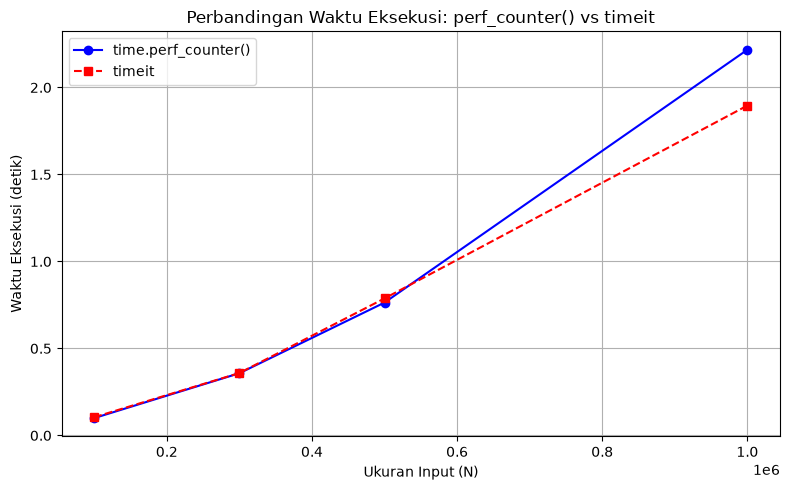

In [8]:
#SOAL 4
import time
import timeit
import matplotlib.pyplot as plt
import pandas as pd

def hitung_faiz(n):
    if n < 2:
        return False
    for i in range(2, int(n**0.5) + 1):
        if n % i == 0:
            return False
    return True

def hitung_semua_faiz(limit):
    return sum(1 for i in range(limit) if hitung_prima(i))
    
input_sizes = [100_000, 300_000, 500_000, 1_000_000]

waktu_perf = []
waktu_timeit = []

for limit in input_sizes:
    # Menggunakan time.perf_counter()
    start = time.perf_counter()
    hitung_semua_prima(limit)
    end = time.perf_counter()
    waktu_perf.append(end - start)

    # Menggunakan timeit (diukur 1 kali eksekusi agar seimbang)
    t = timeit.timeit(lambda: hitung_semua_prima(limit), number=1)
    waktu_timeit.append(t)

df_hasil = pd.DataFrame(
    {
        "Ukuran Input (N)": [f"{n:,}" for n in input_sizes],
        "perf_counter (detik)": [f"{t:.5f}" for t in waktu_perf],
        "timeit (detik)": [f"{t:.5f}" for t in waktu_timeit],
    }
)

print("=== TABEL PERBANDINGAN BENCHMARK ===")
print(df_hasil.to_string(index=False))

plt.figure(figsize=(8, 5))
plt.plot(
    input_sizes, waktu_perf, marker="o", label="time.perf_counter()", color="b"
)
plt.plot(
    input_sizes,
    waktu_timeit,
    marker="s",
    linestyle="--",
    label="timeit",
    color="r",
)

plt.title("Perbandingan Waktu Eksekusi: perf_counter() vs timeit")
plt.xlabel("Ukuran Input (N)")
plt.ylabel("Waktu Eksekusi (detik)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()